Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad
from tensorflow.keras.callbacks import EarlyStopping, TerminateOnNaN

Feature Distribution

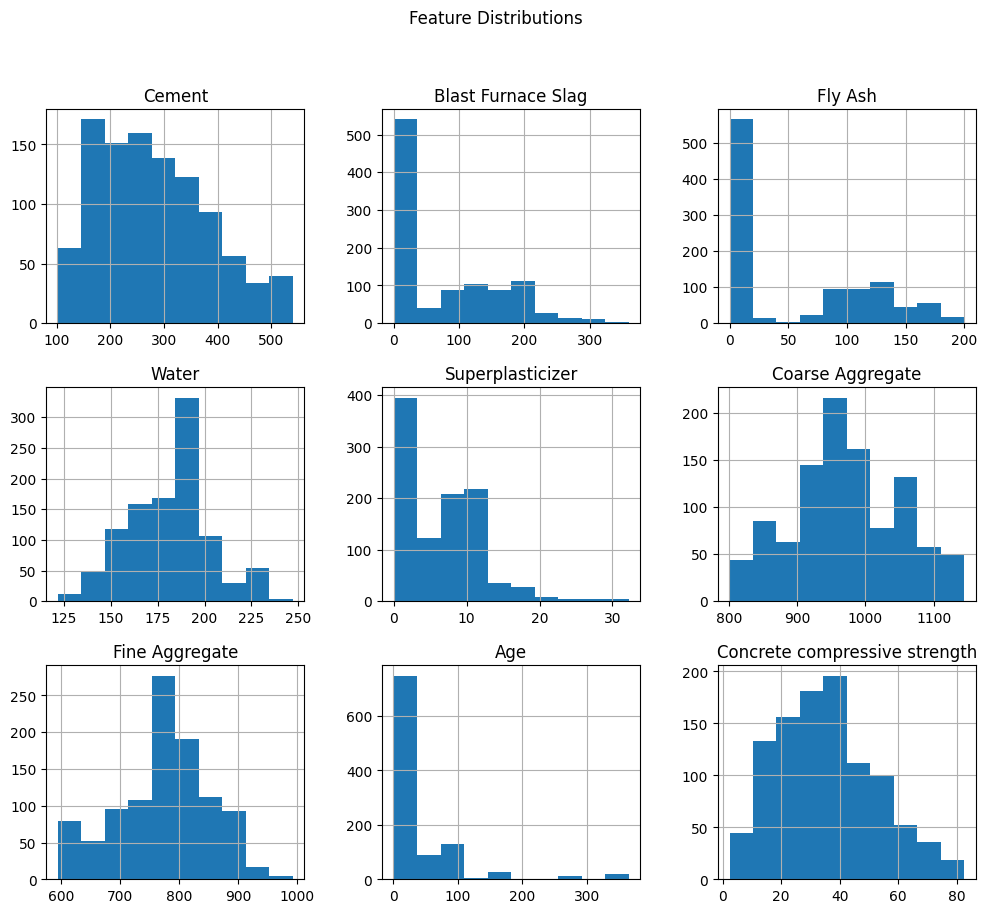

In [ ]:
df = pd.read_excel('Concrete_Data.xls')

df.columns = [col.split('(')[0].strip() for col in df.columns]

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

Box Plots for Outlier Detection

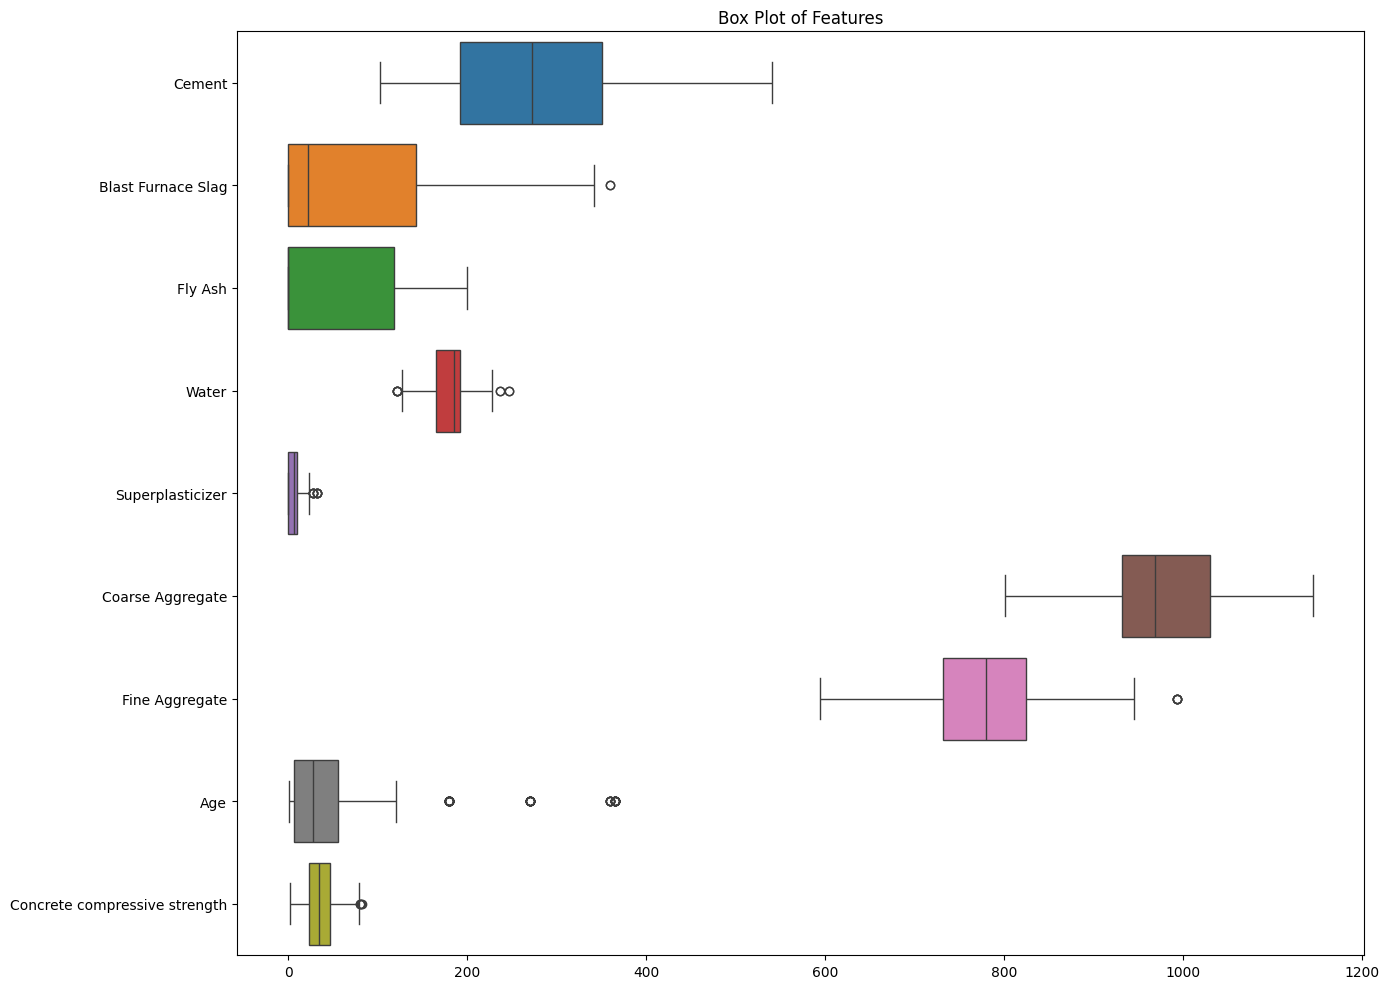

In [ ]:
import os

plt.figure(figsize=(14, 10))
sns.boxplot(data=df, orient='h')
plt.title("Box Plot of Features")
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig("plots/boxplots.png", dpi=300)
plt.show()

Correlation Heatmap

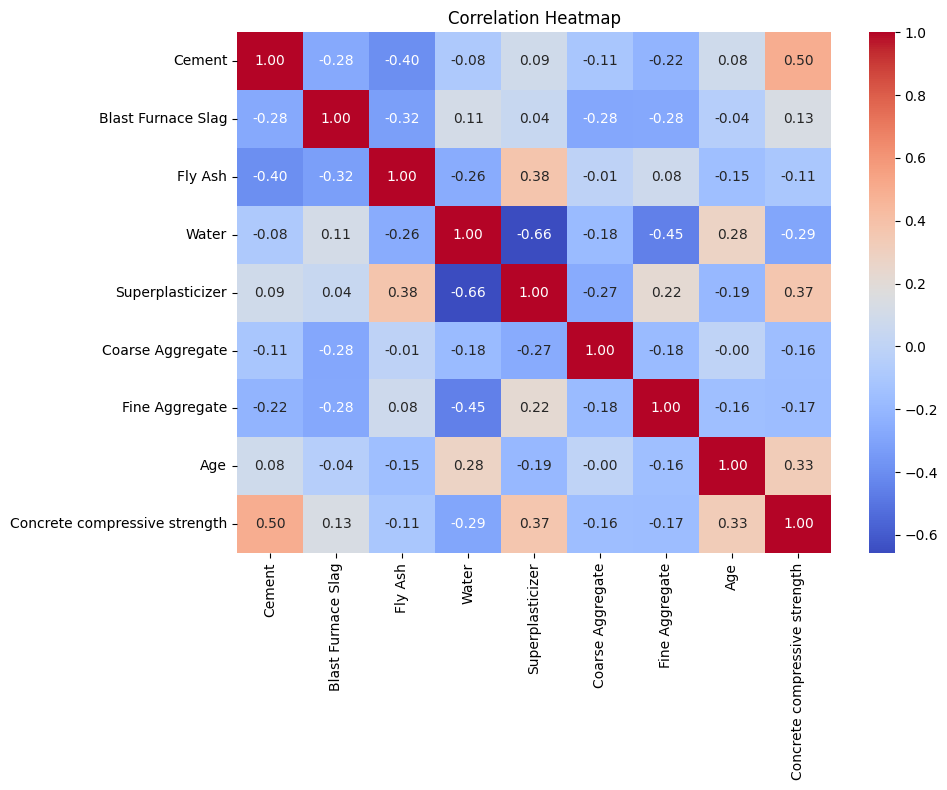

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300)
plt.show()

Data Normalization

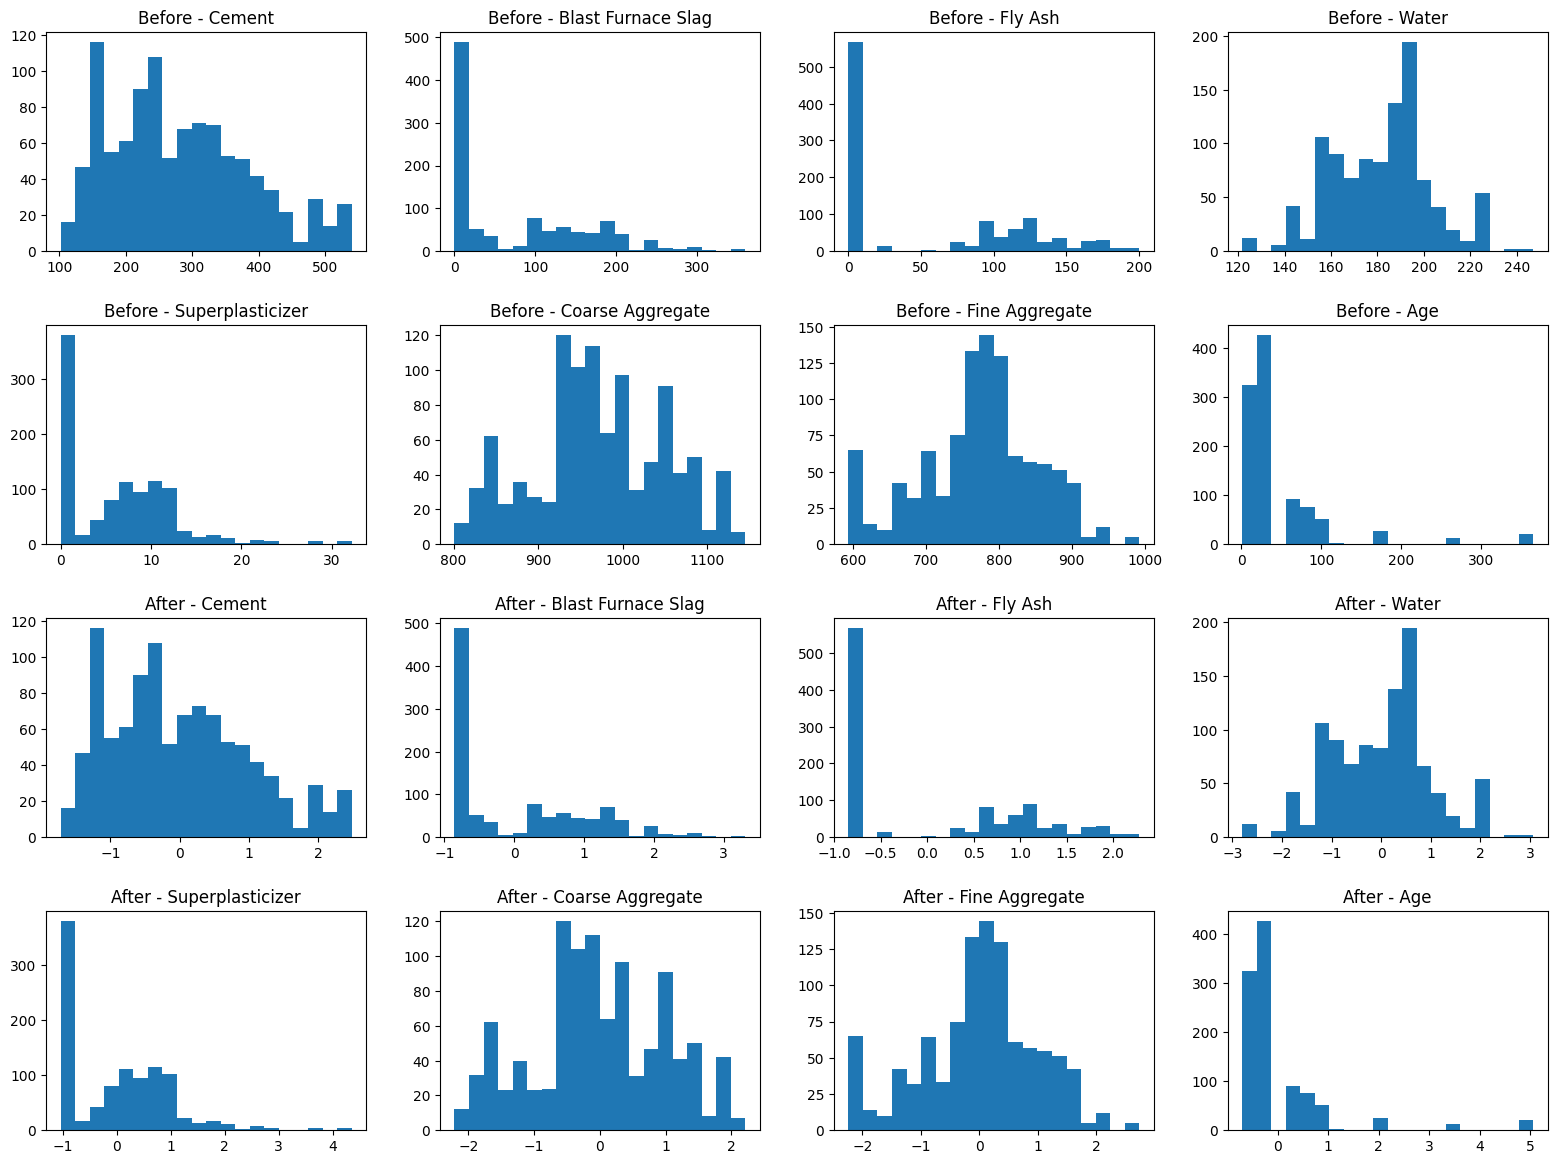

In [ ]:
import math

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

features_to_plot = range(X.shape[1])

n_features = len(features_to_plot)
n_cols = 4
n_rows =4
plt.figure(figsize=(16, n_rows * 3))

loop_a = 0
for loop_a in range(1):
    loop_a += 1

for i, idx in enumerate(features_to_plot):

    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(X.iloc[:, idx], bins=20)
    plt.title(f"Before - {X.columns[idx]}")


    plt.subplot(n_rows, n_cols, i + 1 + n_features)
    plt.hist(X_scaled[:, idx], bins=20)
    plt.title(f"After - {X.columns[idx]}")

plt.tight_layout(pad=2.0)
plt.savefig("plots_comparison.png", dpi=300)
plt.show()

Train Test Data Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (721, 8)
Validation: (154, 8)
Test: (155, 8)


Evaluation Matix consisting of rmse, mae, r2

In [ ]:
def evaluate_model(y_true, y_pred):
    y_pred = np.array(y_pred).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

Baseline ANN Model

In [ ]:
def build_baseline_model():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(16, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

baseline_model = build_baseline_model()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    TerminateOnNaN()
]

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=callbacks
)

Training vs Validation Loss Plot

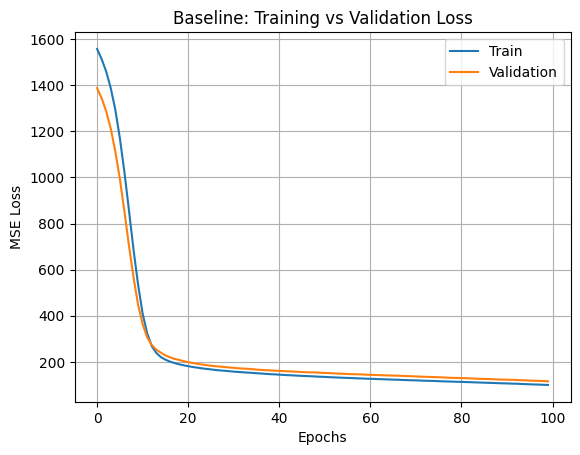

In [ ]:
plt.figure()
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Validation')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Baseline: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("plots/baseline_loss.png", dpi=300)
plt.show()

Prediction and Performance Visualization

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


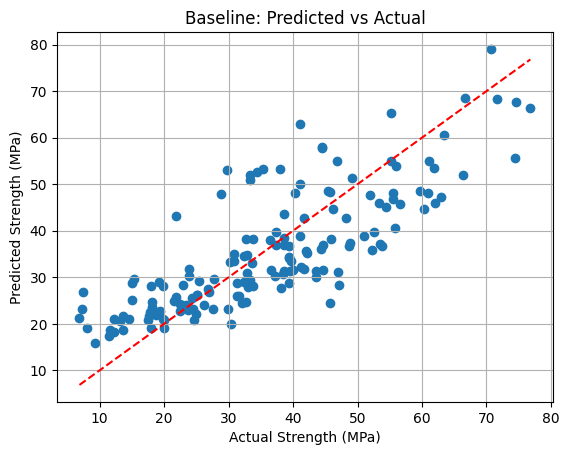

In [ ]:
y_pred_baseline = baseline_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred_baseline)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Baseline: Predicted vs Actual")
plt.grid(True)
plt.savefig("plots/baseline_predicted_vs_actual.png", dpi=300)
plt.show()

3D Actual vs Predicted vs Residual plot

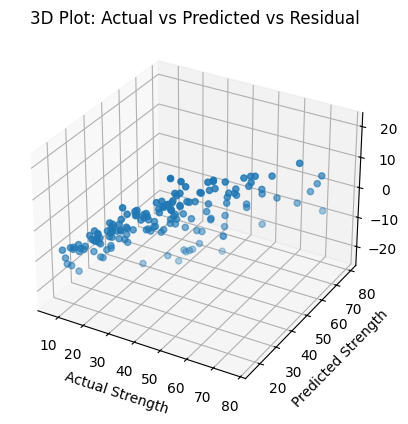

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = y_test.values
y = y_pred_baseline.flatten()
z = x - y  # residuals

ax.scatter(x, y, z)

ax.set_xlabel('Actual Strength')
ax.set_ylabel('Predicted Strength')
ax.set_zlabel('Residual')
ax.set_title('3D Plot: Actual vs Predicted vs Residual')

plt.show()

Baseline Model Performance

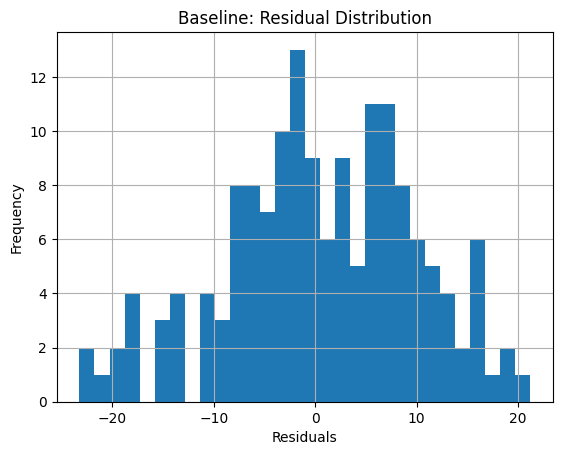


Baseline: Residual Distribution (RMSE, MAE, R2): (np.float64(9.460010321342883), 7.640679993859765, 0.642446815116867)


In [ ]:
errors = y_test - y_pred_baseline.flatten()
plt.figure()
plt.hist(errors, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Baseline: Residual Distribution")
plt.grid(True)
plt.savefig("plots_baseline_residuals.png", dpi=300)
plt.show()

baseline_metrics = evaluate_model(y_test, y_pred_baseline)
print("\nBaseline: Residual Distribution (RMSE, MAE, R2):", baseline_metrics)

Learning Rate Schedules


 Learning Rate Schedules Are As Follows:


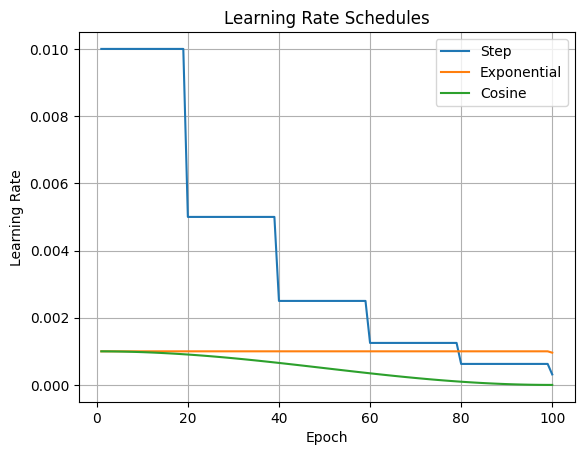

In [ ]:
def step_decay(epoch, initial_lr=0.01, drop=0.5, epochs_drop=20):
    return initial_lr * (drop ** (epoch // epochs_drop))

exp_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100,
    decay_rate=0.96,
    staircase=True
)

cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=100
)

print(f"\n Learning Rate Schedules Are As Follows:")
epochs_range = np.arange(1, 101)
plt.figure()
plt.plot(epochs_range, [step_decay(e) for e in epochs_range], label='Step')
plt.plot(epochs_range, [exp_decay(e).numpy() for e in epochs_range], label='Exponential')
plt.plot(epochs_range, [cosine_decay(e).numpy() for e in epochs_range], label='Cosine')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedules")
plt.legend()
plt.grid(True)
plt.savefig("plots/learning_rate_schedules.png", dpi=300)
plt.show()

In [ ]:
def evaluate_model(y_true, y_pred):
    y_pred = np.array(y_pred).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

Hyperparameter Tuning And Model Evaluation


Baseline Performance (RMSE, MAE, R2): (np.float64(9.460010321342883), 7.640679993859765, 0.642446815116867)

Training Model: adam, Neurons=16, Activation=relu
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Training Model: adam, Neurons=32, Activation=relu


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Training Model: sgd, Neurons=32, Activation=relu
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Training Model: rmsprop, Neurons=64, Activation=tanh
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Training Model: adagrad, Neurons=64, Activation=sigmoid
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Model Comparison:
   Optimizer  Neurons Activation       RMSE        MAE        R2
0      adam       16       relu   9.517927   7.646431  0.638055
1      adam       32       relu   6.487770   5.198368  0.831830
2       sgd       32       relu   6.039421   4.670774  0.854270
3   rmsprop       64       tanh   5.913759   4.782997  0.860272
4   adagrad       64    sigmoid  32.080873  27.991613 -3.111968

Best Model:
 Optimizer      rmsprop
Neurons             64
Activation        tanh
RMSE          5.913759
MAE           4.782997
R2            0.860272
Name: 3, dtype: object


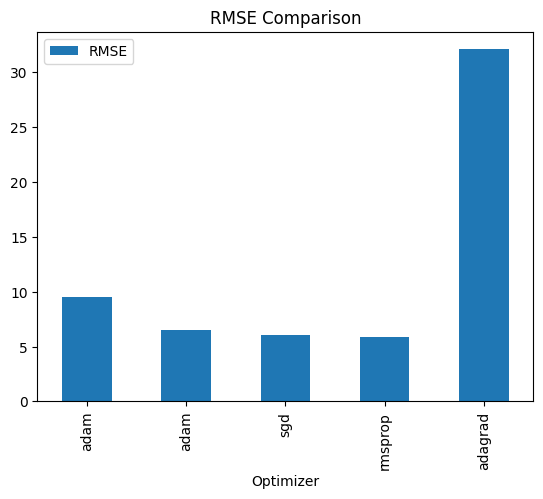

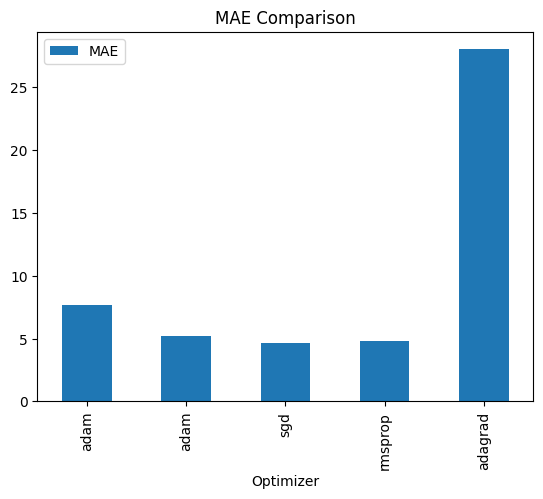

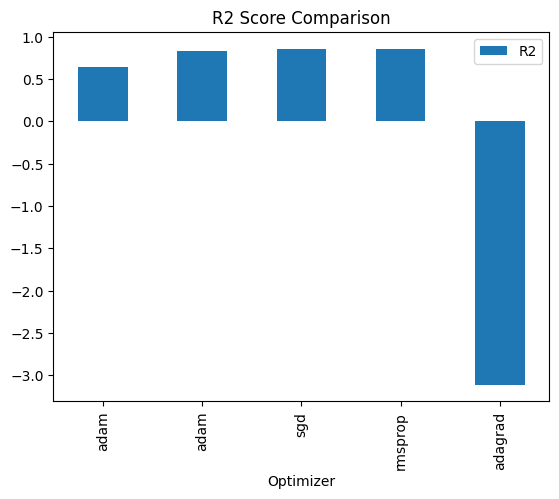

In [ ]:
baseline_metrics = evaluate_model(y_test, y_pred_baseline)
print("\nBaseline Performance (RMSE, MAE, R2):", baseline_metrics)

def build_baseline_model(optimizer_name, num_neurons, activation_function):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(num_neurons, activation=activation_function),
        Dense(num_neurons, activation=activation_function),
        Dense(1, activation='linear')
    ])


    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=0.001)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=0.001)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=0.001)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=0.001)
    else:

        optimizer = Adam(learning_rate=0.001)

    model.compile(optimizer=optimizer, loss='mse')
    return model

configs = [
    ('adam', 16, 'relu'),
    ('adam', 32, 'relu'),
    ('sgd', 32, 'relu'),
    ('rmsprop', 64, 'tanh'),
    ('adagrad', 64, 'sigmoid')
]

results = []

for opt, neurons, act in configs:
    print(f"\nTraining Model: {opt}, Neurons={neurons}, Activation={act}")

    model = build_baseline_model(opt, neurons, act)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    y_pred = model.predict(X_test)
    rmse, mae, r2 = evaluate_model(y_test, y_pred)

    results.append({
        'Optimizer': opt,
        'Neurons': neurons,
        'Activation': act,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })


results_df = pd.DataFrame(results)
print("\nModel Comparison:\n", results_df)


best_model = results_df.loc[results_df['RMSE'].idxmin()]
print("\nBest Model:\n", best_model)

results_df.plot(x='Optimizer', y='RMSE', kind='bar')
plt.title("RMSE Comparison")
plt.show()

results_df.plot(x='Optimizer', y='MAE', kind='bar')
plt.title("MAE Comparison")
plt.show()

results_df.plot(x='Optimizer', y='R2', kind='bar')
plt.title("R2 Score Comparison")
plt.show()

3D Visualization

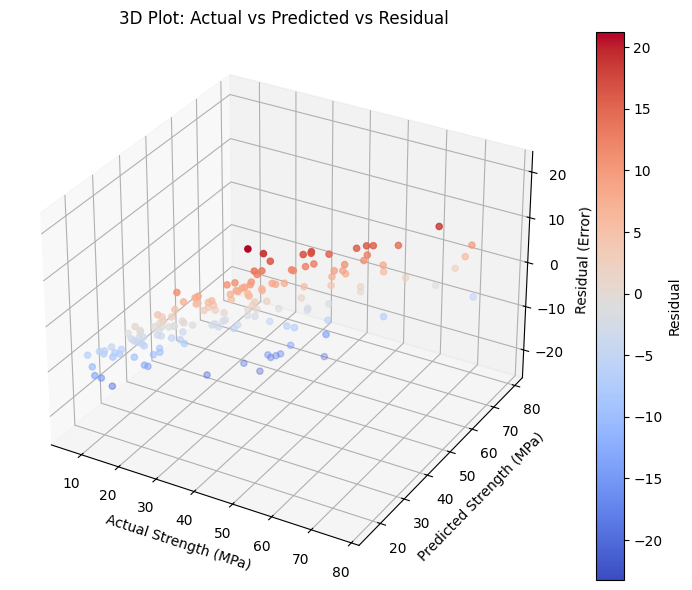

In [ ]:
from mpl_toolkits.mplot3d import Axes3D


actual = y_test.values
predicted = y_pred_baseline.flatten()
residuals = actual - predicted


fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(actual, predicted, residuals, c=residuals, cmap='coolwarm')
fig.colorbar(scatter, ax=ax, label='Residual')


ax.set_xlabel('Actual Strength (MPa)')
ax.set_ylabel('Predicted Strength (MPa)')
ax.set_zlabel('Residual (Error)')

ax.set_title('3D Plot: Actual vs Predicted vs Residual')

plt.tight_layout()
plt.show()